In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [68]:
df = pd.read_csv("./rendimento_pecas.csv")
df

,Regiao,Produto,valor_por_kg,Aproveita,Peso
0,Traseiro,Filé,55.39,1,4.4
1,Traseiro,Contrafilé,33.65,1,14.4
2,Traseiro,Alcatra,42.36,1,11.5
3,Traseiro,Coxão mole,29.49,1,16.4
4,Traseiro,Coxão duro,27.96,1,11.0
5,Traseiro,Patinho,29.27,1,10.0
6,Traseiro,Lagarto,27.80,1,4.6
7,Traseiro,Capa e aba,26.06,1,3.6
8,Traseiro,Músculo Traseiro,23.44,1,7.6
9,Traseiro,Retalhos,0.00,0,6.0


In [69]:
df["Proporcao"] = df.Peso / 250
df.drop("Peso", axis="columns", inplace=True)
df["Proporcao x valor_por_kg "] = df["valor_por_kg"] * df["Proporcao"]
df.head()

,Regiao,Produto,valor_por_kg,Aproveita,Proporcao,Proporcao x valor_por_kg
0,Traseiro,Filé,55.39,1,0.0176,0.974864
1,Traseiro,Contrafilé,33.65,1,0.0576,1.938240
2,Traseiro,Alcatra,42.36,1,0.0460,1.948560
3,Traseiro,Coxão mole,29.49,1,0.0656,1.934544
4,Traseiro,Coxão duro,27.96,1,0.0440,1.230240


In [59]:
agrupado = df.groupby("Regiao")["Proporcao"].sum()

agrupado

Regiao
Dianteiro          0.3800
Ponta de Agulha    0.1400
Traseiro           0.4796
Name: Proporcao, dtype: float64

In [60]:
agrupadoValor = df.groupby("Regiao")["valor_por_kg"].agg(["sum", "mean", "max"])
agrupadoValor

,sum,mean,max
Regiao,,,
Dianteiro,129.04,14.337778,33.03
Ponta de Agulha,0.00,0.000000,0.00
Traseiro,295.42,24.618333,55.39


In [61]:
df_aproveita = df[df["Aproveita"] == 1]
df_descarta = df[df["Aproveita"] == 0]

rendimento = df_aproveita["Proporcao"].sum()

In [62]:
df_aproveita.columns

Index(['Regiao', 'Produto', 'valor_por_kg', 'Aproveita', 'Proporcao'], dtype='object')

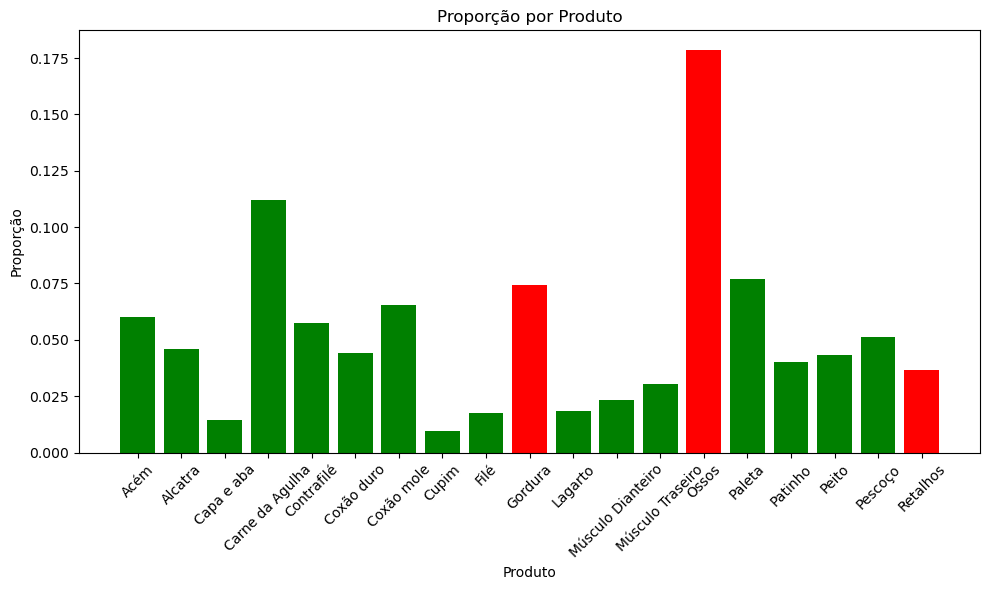

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que df tem: ['Produto', 'Proporcao', 'Aproveita']
# Se existir mais de uma linha por produto, agrupe e mantenha o valor de "Aproveita"
df_grouped = (
    df.groupby("Produto")
    .agg(
        {
            "Proporcao": "sum",
            "Aproveita": "first",  # ou "max"/"any", dependendo da lógica
        }
    )
    .reset_index()
)

# Definir cores baseadas na coluna "Aproveita"
# Suponha que "Aproveita" contenha 1 (sim) e 0 (não)
cores = df_grouped["Aproveita"].map(
    {1: "green", 0: "red"}
)  # ou mapeie outras cores como quiser

# Plot
plt.figure(figsize=(10, 6))
plt.bar(df_grouped["Produto"], df_grouped["Proporcao"], color=cores)
plt.xlabel("Produto")
plt.ylabel("Proporção")
plt.title("Proporção por Produto")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

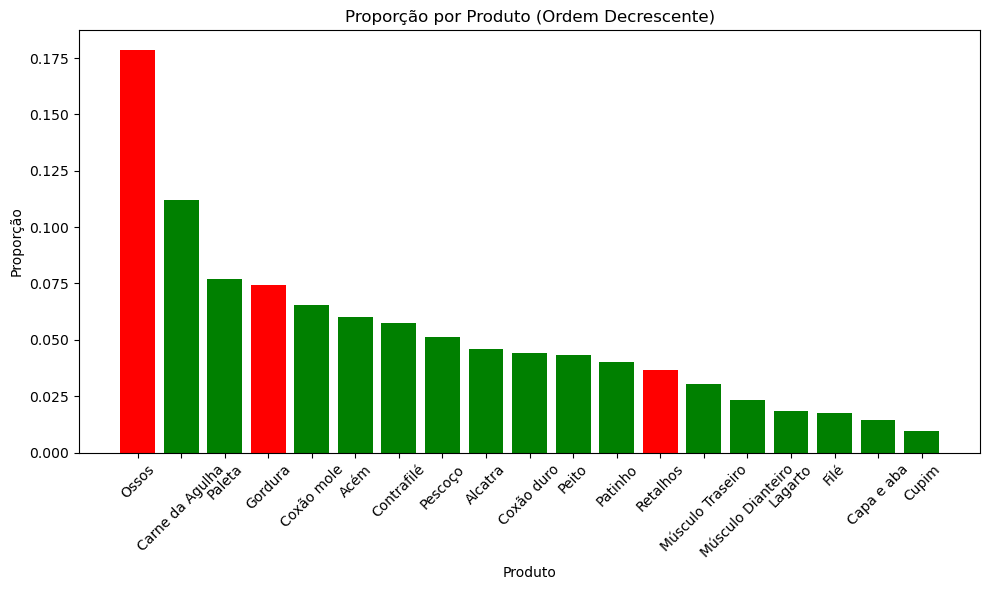

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# Agrupar e manter um valor representativo de 'Aproveita'
df_grouped = (
    df.groupby("Produto").agg({"Proporcao": "sum", "Aproveita": "first"}).reset_index()
)

# Ordenar em ordem decrescente de 'Proporcao'
df_grouped = df_grouped.sort_values(by="Proporcao", ascending=False)

# Mapear cores com base na coluna 'Aproveita'
cores = df_grouped["Aproveita"].map({1: "green", 0: "red"})

# Plot
plt.figure(figsize=(10, 6))
plt.bar(df_grouped["Produto"], df_grouped["Proporcao"], color=cores)
plt.xlabel("Produto")
plt.ylabel("Proporção")
plt.title("Proporção por Produto (Ordem Decrescente)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

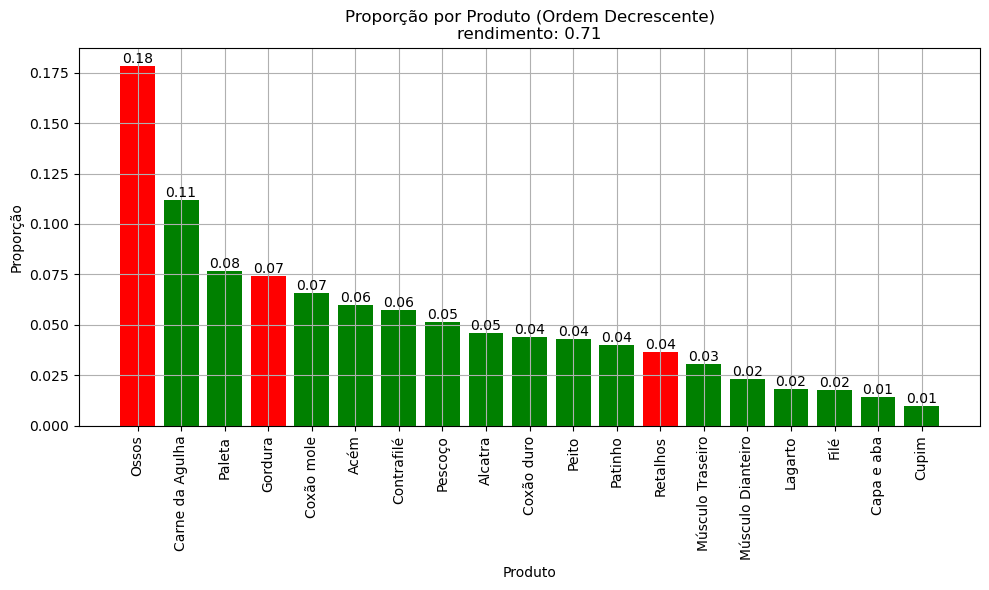

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Agrupar e manter um valor representativo de 'Aproveita'
df_grouped = (
    df.groupby("Produto").agg({"Proporcao": "sum", "Aproveita": "first"}).reset_index()
)

# Ordenar em ordem decrescente de 'Proporcao'
df_grouped = df_grouped.sort_values(by="Proporcao", ascending=False)

# Mapear cores com base na coluna 'Aproveita'
cores = df_grouped["Aproveita"].map({1: "green", 0: "red"})

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(df_grouped["Produto"], df_grouped["Proporcao"], color=cores)
plt.xlabel("Produto")
plt.ylabel("Proporção")
plt.title(f"Proporção por Produto (Ordem Decrescente)\nrendimento: {rendimento}")
plt.xticks(rotation=90)
plt.grid()

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # centro da barra
        height,  # posição vertical (topo da barra)
        f"{height:.2f}",  # formatação com 2 casas decimais
        ha="center",  # alinhamento horizontal
        va="bottom",  # alinhamento vertical
    )

plt.tight_layout()
plt.show()

In [70]:
df.columns

Index(['Regiao', 'Produto', 'valor_por_kg', 'Aproveita', 'Proporcao',
       'Proporcao x valor_por_kg '],
      dtype='object')

In [81]:
df["Regiao"].unique()

array(['Traseiro', 'Dianteiro', 'Ponta de Agulha'], dtype=object)

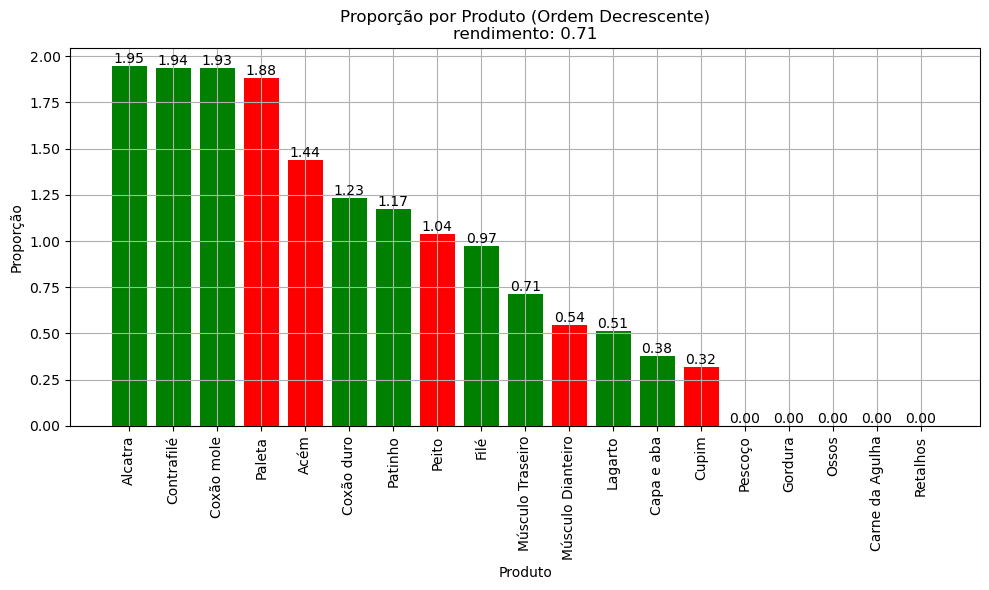

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

# Agrupar e manter um valor representativo de 'Aproveita'
df_grouped = (
    df.groupby("Produto")
    .agg(
        {
            "Proporcao x valor_por_kg ": "sum",
            "Aproveita": "first",
            "Regiao": "first",  # <-- Adiciona essa linha
        }
    )
    .reset_index()
)

# Ordenar em ordem decrescente de 'Proporcao'
df_grouped = df_grouped.sort_values(by="Proporcao x valor_por_kg ", ascending=False)

# Mapear cores com base na coluna 'Aproveita'
cores = df_grouped["Regiao"].map(
    {"Traseiro": "green", "Dianteiro": "red", "Ponta de Agulha": "blue"}
)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(
    df_grouped["Produto"], df_grouped["Proporcao x valor_por_kg "], color=cores
)
plt.xlabel("Produto")
plt.ylabel("Proporção")
plt.title(f"Proporção por Produto (Ordem Decrescente)\nrendimento: {rendimento}")
plt.xticks(rotation=90)
plt.grid()

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # centro da barra
        height,  # posição vertical (topo da barra)
        f"{height:.2f}",  # formatação com 2 casas decimais
        ha="center",  # alinhamento horizontal
        va="bottom",  # alinhamento vertical
    )

plt.tight_layout()
plt.show()

In [73]:
agrupadoValorAgregado = df.groupby("Regiao")["Proporcao x valor_por_kg "].sum()
agrupadoValorAgregado

Regiao
Dianteiro           5.222992
Ponta de Agulha     0.000000
Traseiro           10.796608
Name: Proporcao x valor_por_kg , dtype: float64